# Eagles x SOPP Data Wrangling

In [1]:
import pandas as pd
import numpy as np

## Import Data Sets

In [2]:
philly_stops = pd.read_csv("../data/pa_philadelphia_2020_04_01.csv")
#philly_stops = pd.read_csv("pa_philadelphia_2020_04_01.csv")

/var/folders/k9/6ttfwb0s7ssb63rlmgdbybc80000gn/T/ipykernel_2631/4194843348.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  philly_stops = pd.read_csv("../data/pa_philadelphia_2020_04_01.csv")


In [3]:
philly_stops

,raw_row_number,date,time,location,lat,lng,district,service_area,subject_age,subject_race,...,arrest_made,outcome,contraband_found,frisk_performed,search_conducted,search_person,search_vehicle,raw_race,raw_individual_contraband,raw_vehicle_contraband
0,411981,2014-01-01,01:14:00,NaN,NaN,NaN,19.0,191,31.0,black,...,True,arrest,True,False,True,True,False,Black - Non-Latino,True,False
1,407442,2014-01-01,01:57:00,NaN,NaN,NaN,12.0,121,21.0,black,...,True,arrest,False,True,True,True,False,Black - Non-Latino,False,False
2,217556,2014-01-01,03:30:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,24.0,black,...,False,NaN,NaN,False,False,False,False,Black - Non-Latino,False,False
3,217557,2014-01-01,03:40:00,3400 BLOCK SPRUCE ST,39.950424,-75.192680,18.0,183,20.0,black,...,False,NaN,NaN,False,False,False,False,Black - Non-Latino,False,False
4,230988,2014-01-01,08:30:00,N 56TH ST / UPLAND WAY,39.983712,-75.234188,19.0,193,31.0,black,...,False,NaN,NaN,False,False,False,False,Black - Non-Latino,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1865091,1791698,2018-04-14,21:36:00,S 59TH ST / ELMWOOD AV,39.928084,-75.221956,12.0,123,60.0,black,...,False,NaN,NaN,False,False,False,False,Black - Non-Latino,False,False
1865092,1789312,2018-04-14,22:01:00,2600 BLOCK JUDSON ST,39.998242,-75.175190,39.0,393,33.0,asian/pacific islander,...,False,NaN,NaN,False,False,False,False,Asian,False,False
1865093,1791237,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,21.0,black,...,True,arrest,False,True,True,True,False,Black - Non-Latino,False,False
1865094,1791243,2018-04-14,22:48:00,500 BLOCK E OLNEY AV,40.033812,-75.114429,35.0,352,22.0,black,...,True,arrest,False,True,True,True,False,Black - Non-Latino,False,False


In [4]:
eagles = pd.read_csv("../data/cleanedEaglesData.csv")
# eagles = pd.read_csv("cleanedEaglesData.csv")
eagles

,Game,Day,Date,StartTime,xEndTime,Home,Opp,TeamScore,OppScore,PointDiff,...,Wins,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl
0,1,Sunday,2014-09-07,13:02:00,16:14:00,0,Jacksonville Jaguars,34,17,17,...,1,0,1,0,0,0,1,0,0,0
1,2,Monday,2014-09-15,20:31:00,23:43:00,1,Indianapolis Colts,30,27,3,...,2,0,2,0,0,0,1,0,0,0
2,3,Sunday,2014-09-21,13:02:00,16:14:00,0,Washington Redskins,37,34,3,...,3,0,3,0,0,0,1,0,0,0
3,4,Sunday,2014-09-28,16:25:00,19:37:00,1,San Francisco 49ers,21,26,-5,...,3,1,-1,0,0,0,1,0,0,0
4,5,Sunday,2014-10-05,13:02:00,16:14:00,0,St. Louis Rams,34,28,6,...,4,1,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,16,Monday,2017-12-25,20:30:00,23:42:00,0,Oakland Raiders,19,10,9,...,13,2,3,0,0,0,1,0,0,0
63,17,Sunday,2017-12-31,13:00:00,16:12:00,0,Dallas Cowboys,0,6,-6,...,13,3,-1,1,0,1,1,0,0,0
64,Division,Saturday,2018-01-13,16:35:00,19:47:00,0,Atlanta Falcons,15,10,5,...,14,3,1,0,0,0,0,1,0,0
65,Conf. Champ.,Sunday,2018-01-21,18:40:00,21:52:00,0,Minnesota Vikings,38,7,31,...,15,3,2,0,0,0,0,0,1,0


In [5]:
eagles.columns

Index(['Game', 'Day', 'Date', 'StartTime', 'xEndTime', 'Home', 'Opp',
       'TeamScore', 'OppScore', 'PointDiff', 'DefTO', 'OffTO', 'TODiff', 'Win',
       'OT', 'Season', 'Wins', 'Losses', 'Streak', 'Rivalry', 'Giants',
       'Cowboys', 'RegularSeason', 'Division', 'ConfChamp', 'SuperBowl'],
      dtype='object')

In [6]:
philly_stops.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'service_area', 'subject_age', 'subject_race', 'subject_sex', 'type',
       'arrest_made', 'outcome', 'contraband_found', 'frisk_performed',
       'search_conducted', 'search_person', 'search_vehicle', 'raw_race',
       'raw_individual_contraband', 'raw_vehicle_contraband'],
      dtype='object')

## Parse Date columns

In [7]:
philly_stops['date'] = pd.to_datetime(philly_stops['date'], format='mixed', errors='coerce').dt.date

In [8]:
eagles['Date'] = pd.to_datetime(eagles['Date']).dt.date

In [9]:
philly_stops = philly_stops.dropna(subset=['date'])

In [10]:
philly_stops['date'].head()

0    2014-01-01
1    2014-01-01
2    2014-01-01
3    2014-01-01
4    2014-01-01
Name: date, dtype: object

## Create region (rings) column using latitute and longitude

### Drop unnecessary columns

In [11]:
philly_stops = philly_stops.iloc[:, [1, 2, 4, 5]]
philly_stops.columns

Index(['date', 'time', 'lat', 'lng'], dtype='object')

### Remove NA value rows

In [12]:
# Check % of na values first
philly_stops.isna().mean() * 100

philly_stops = philly_stops.dropna()
philly_stops

,date,time,lat,lng
2,2014-01-01,03:30:00,39.950424,-75.192680
3,2014-01-01,03:40:00,39.950424,-75.192680
4,2014-01-01,08:30:00,39.983712,-75.234188
5,2014-01-01,08:53:00,39.953124,-75.181936
6,2014-01-01,09:00:00,39.989757,-75.229019
...,...,...,...,...
1865091,2018-04-14,21:36:00,39.928084,-75.221956
1865092,2018-04-14,22:01:00,39.998242,-75.175190
1865093,2018-04-14,22:48:00,40.033812,-75.114429
1865094,2018-04-14,22:48:00,40.033812,-75.114429


### Create 5 regions (ring shape) with a 1 km radius. Everything further is NA

### This uses the Haversine formula instead of Euclidean distance which is apparently the norm for calculating distance with latitude and longitude, but we can look more into this

In [13]:
import numpy as np

# Stadium coordinates
stadium_lat = 39.9014
stadium_lng = -75.1676

# Convert to radians
lat1 = np.radians(philly_stops['lat'])
lon1 = np.radians(philly_stops['lng'])
lat2 = np.radians(stadium_lat)
lon2 = np.radians(stadium_lng)

# Haversine formula
dlat = lat1 - lat2
dlon = lon1 - lon2

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

earth_radius_km = 6371
philly_stops['distance_km'] = earth_radius_km * c

# Create region rings
philly_stops['region'] = np.ceil(philly_stops['distance_km']).astype('Int64')

# Set regions > 5 km to NA
philly_stops.loc[philly_stops['region'] > 5, 'region'] = pd.NA
philly_stops


,date,time,lat,lng,distance_km,region
2,2014-01-01,03:30:00,39.950424,-75.192680,5.855768,<NA>
3,2014-01-01,03:40:00,39.950424,-75.192680,5.855768,<NA>
4,2014-01-01,08:30:00,39.983712,-75.234188,10.770188,<NA>
5,2014-01-01,08:53:00,39.953124,-75.181936,5.879916,<NA>
6,2014-01-01,09:00:00,39.989757,-75.229019,11.132890,<NA>
...,...,...,...,...,...,...
1865091,2018-04-14,21:36:00,39.928084,-75.221956,5.504073,<NA>
1865092,2018-04-14,22:01:00,39.998242,-75.175190,10.787800,<NA>
1865093,2018-04-14,22:48:00,40.033812,-75.114429,15.405070,<NA>
1865094,2018-04-14,22:48:00,40.033812,-75.114429,15.405070,<NA>


### Drop  observations outside the 5 km radius

In [14]:
# look at NAs first
philly_stops['region'].value_counts(dropna=False) # Indicates a lot more observations outside the 5 km radius

# drop region NAs (indicates far from stadium)
philly_stops.dropna(subset=['region'], inplace=True)

### Drop extra location columns

In [15]:
philly_stops.drop(columns=['lat', 'lng', 'distance_km'], inplace=True)
philly_stops

,date,time,region
215,2014-01-04,20:50:00,3
368,2014-01-08,10:07:00,3
435,2014-01-08,22:45:00,3
816,2014-01-13,09:10:00,3
819,2014-01-13,09:49:00,3
...,...,...,...
1865051,2018-04-14,21:00:00,5
1865073,2018-04-14,21:16:00,2
1865074,2018-04-14,21:17:00,5
1865075,2018-04-14,21:19:00,4


## Aggregate stops by date, region, and hour

### Convert time to hour block

In [16]:
philly_stops['hour'] = pd.to_datetime(philly_stops['time'], format='%H:%M:%S').dt.hour
philly_stops.head()

,date,time,region,hour
215,2014-01-04,20:50:00,3,20
368,2014-01-08,10:07:00,3,10
435,2014-01-08,22:45:00,3,22
816,2014-01-13,09:10:00,3,9
819,2014-01-13,09:49:00,3,9


In [17]:
# Drop time column
philly_stops.drop(columns=['time'], inplace=True)
philly_stops.head()

,date,region,hour
215,2014-01-04,3,20
368,2014-01-08,3,10
435,2014-01-08,3,22
816,2014-01-13,3,9
819,2014-01-13,3,9


### Aggregate (count) the number of stops for each date, region, hour combination

In [18]:
aggregate_philly_stops = (
    philly_stops
    .groupby(['date', 'hour', 'region'])
    .size()
    .reset_index(name='stop_count')
)

aggregate_philly_stops

,date,hour,region,stop_count
0,2014-01-04,20,3,1
1,2014-01-08,10,3,1
2,2014-01-08,22,3,1
3,2014-01-13,9,3,2
4,2014-01-13,11,2,1
...,...,...,...,...
77879,2018-04-14,20,4,4
77880,2018-04-14,20,5,6
77881,2018-04-14,21,2,1
77882,2018-04-14,21,4,1


## Fill 0 stops for any missing combinations

In [19]:
# Create full index of all combinations
full_index = pd.MultiIndex.from_product(
    [
        aggregate_philly_stops['date'].unique(),     # all dates
        range(24),               # hours 0–23
        range(1, 6)              # regions 1–5
    ],
    names=['date', 'hour', 'region']
)

# Reindex dataframe
aggregate_philly_stops = (
    aggregate_philly_stops.set_index(['date', 'hour', 'region'])
      .reindex(full_index, fill_value=0)
      .reset_index()
)
pd.to_datetime(eagles['Date']).dt.date

aggregate_philly_stops


,date,hour,region,stop_count
0,2014-01-04,0,1,0
1,2014-01-04,0,2,0
2,2014-01-04,0,3,0
3,2014-01-04,0,4,0
4,2014-01-04,0,5,0
...,...,...,...,...
186355,2018-04-14,23,1,0
186356,2018-04-14,23,2,0
186357,2018-04-14,23,3,0
186358,2018-04-14,23,4,0


## Add game information and home game flag to stop data

### First, check that all gamedays are in the stop data

In [20]:
missing_dates = eagles.loc[~eagles['Date'].isin(aggregate_philly_stops['date']), 'Date']

missing_dates


Series([], Name: Date, dtype: object)

 ### Left join philly stops with Eagles data

In [21]:
# Merge (left join keeps all philly_stops rows)
# non-gamedays will have NA in all Eagles columns
merged_df = aggregate_philly_stops.merge(
    eagles,
    how='left',
    left_on='date',
    right_on='Date'
)

In [22]:
# Check that all gamedays are in the final dataset.
merged_df['Date'].nunique()

67

### Create gameday indicator column

In [23]:
# Create gameday indicator (1 if matched with Eagles game, else 0)
merged_df['gameday'] = merged_df['Date'].notna().astype(int)

# Drop the Eagles date column
merged_df = merged_df.drop(columns=['Date'])
merged_df

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday
0,2014-01-04,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2014-01-04,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2014-01-04,0,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2014-01-04,0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2014-01-04,0,5,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186355,2018-04-14,23,1,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
186356,2018-04-14,23,2,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
186357,2018-04-14,23,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
186358,2018-04-14,23,4,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Calculate baseline using non-gamedays

In [24]:
non_gamedays = merged_df[merged_df['gameday'] == 0].copy()
non_gamedays.head()

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday
0,2014-01-04,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2014-01-04,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2014-01-04,0,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2014-01-04,0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2014-01-04,0,5,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [25]:
baseline_stops = (
    non_gamedays
    .groupby(['hour', 'region'])['stop_count']
    .mean()
    .reset_index(name='baseline')
)
baseline_stops = baseline_stops[['hour', 'region', 'baseline']]
baseline_stops

,hour,region,baseline
0,0,1,0.117093
1,0,2,0.488560
2,0,3,1.687752
3,0,4,2.969044
4,0,5,2.618439
...,...,...,...
115,23,1,0.056528
116,23,2,0.436743
117,23,3,1.556528
118,23,4,2.187079


## Add before/after column for gamedays

### Filter to just gamedays

In [26]:
gamedays = merged_df[merged_df['gameday'] == 1].copy()
gamedays

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Losses,Streak,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday
28560,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
28561,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
28562,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
28563,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
28564,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
178076,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
178077,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
178078,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


### Create start/end columns that are rounded to the nearest hour

In [27]:
gamedays['start_hour'] = (pd.to_datetime(gamedays['StartTime'], format='%H:%M:%S')
                          .dt.round('h') # round to the nearest hour
                          .dt.hour
                          )
gamedays['end_hour'] = (pd.to_datetime(gamedays['xEndTime'], format='%H:%M:%S')
                        .dt.round('h') # round to the nearest hour
                        .dt.hour
                        )
gamedays

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Rivalry,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour
28560,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16
28561,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16
28562,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16
28563,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16
28564,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22
178076,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22
178077,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22
178078,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22


### Classify each row as before/after/during the game

In [28]:
conditions = [
    gamedays['hour'] < gamedays['start_hour'],
    (gamedays['hour'] >= gamedays['start_hour']) & (gamedays['hour'] <= gamedays['end_hour']),
    gamedays['hour'] > gamedays['end_hour']
]

choices = ['before', 'during', 'after']

gamedays['game_period'] = np.select(conditions, choices, default="unknown")
gamedays

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Giants,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period
28560,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
28561,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
28562,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
28563,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
28564,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,0.0,1.0,0.0,0.0,0.0,1,13,16,before
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
178076,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
178077,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after
178078,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,0.0,1.0,1,18,22,after


In [29]:
# Check for any errors
gamedays['game_period'].value_counts()

game_period
before    5315
after     1695
during    1030
Name: count, dtype: int64

## Calculate percent change target variable

### Merge with the previously calculated (using non-gamedays) baseline values on hour and region

In [30]:
gamedays = gamedays.merge(
    baseline_stops,
    on=['hour', 'region'],
    how='left'
)
gamedays

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,Cowboys,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period,baseline
0,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1,13,16,before,0.117093
1,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1,13,16,before,0.488560
2,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1,13,16,before,1.687752
3,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1,13,16,before,2.969044
4,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,0.0,1.0,0.0,0.0,0.0,1,13,16,before,2.618439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,1.0,1,18,22,after,0.056528
8036,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,1.0,1,18,22,after,0.436743
8037,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,1.0,1,18,22,after,1.556528
8038,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,0.0,1.0,1,18,22,after,2.187079


In [31]:
gamedays['percent_change_in_stops'] = (
    (gamedays['stop_count'] - gamedays['baseline']) /
    gamedays['baseline']
)
gamedays

,date,hour,region,stop_count,Game,Day,StartTime,xEndTime,Home,Opp,...,RegularSeason,Division,ConfChamp,SuperBowl,gameday,start_hour,end_hour,game_period,baseline,percent_change_in_stops
0,2014-09-07,0,1,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,1.0,0.0,0.0,0.0,1,13,16,before,0.117093,-1.000000
1,2014-09-07,0,2,0,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,1.0,0.0,0.0,0.0,1,13,16,before,0.488560,-1.000000
2,2014-09-07,0,3,1,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,1.0,0.0,0.0,0.0,1,13,16,before,1.687752,-0.407496
3,2014-09-07,0,4,14,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,1.0,0.0,0.0,0.0,1,13,16,before,2.969044,3.715322
4,2014-09-07,0,5,3,1,Sunday,13:02:00,16:14:00,0.0,Jacksonville Jaguars,...,1.0,0.0,0.0,0.0,1,13,16,before,2.618439,0.145721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,2018-02-04,23,1,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,1.0,1,18,22,after,0.056528,-1.000000
8036,2018-02-04,23,2,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,1.0,1,18,22,after,0.436743,-1.000000
8037,2018-02-04,23,3,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,1.0,1,18,22,after,1.556528,-1.000000
8038,2018-02-04,23,4,0,SuperBowl,Sunday,18:30:00,21:42:00,0.0,New England Patriots,...,0.0,0.0,0.0,1.0,1,18,22,after,2.187079,-1.000000


## Clean and Export final dataset

### Drop unnecessary columns here (Feel free to add more!)

In [32]:
final_df = gamedays.copy()

final_df.drop(columns=['baseline'], inplace=True)


In [33]:
final_df.to_csv('eagles_modeling_df.csv')

## **Observing Wrangled Data**

In [34]:
final_df.columns

Index(['date', 'hour', 'region', 'stop_count', 'Game', 'Day', 'StartTime',
       'xEndTime', 'Home', 'Opp', 'TeamScore', 'OppScore', 'PointDiff',
       'DefTO', 'OffTO', 'TODiff', 'Win', 'OT', 'Season', 'Wins', 'Losses',
       'Streak', 'Rivalry', 'Giants', 'Cowboys', 'RegularSeason', 'Division',
       'ConfChamp', 'SuperBowl', 'gameday', 'start_hour', 'end_hour',
       'game_period', 'percent_change_in_stops'],
      dtype='object')

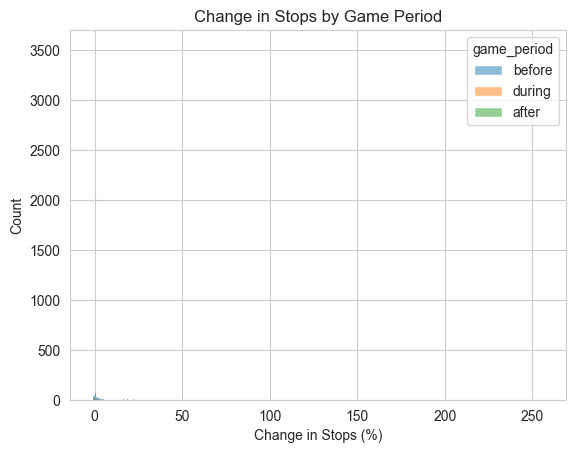

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=final_df,
             x="percent_change_in_stops",
             hue="game_period")

plt.title("Change in Stops by Game Period")
plt.xlabel("Change in Stops (%)")
plt.show()

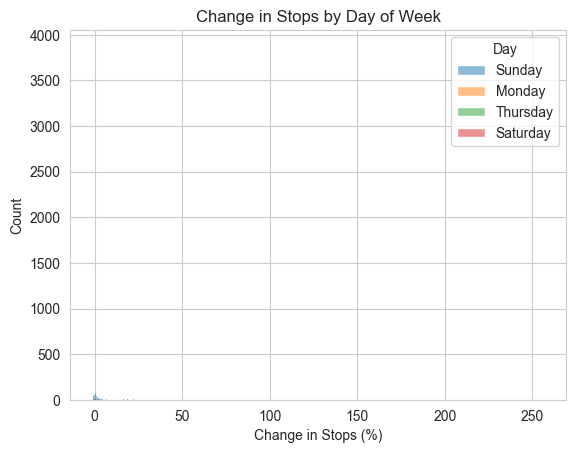

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=final_df,
             x="percent_change_in_stops",
             hue="Day")

plt.title("Change in Stops by Day of Week")
plt.xlabel("Change in Stops (%)")
plt.show()

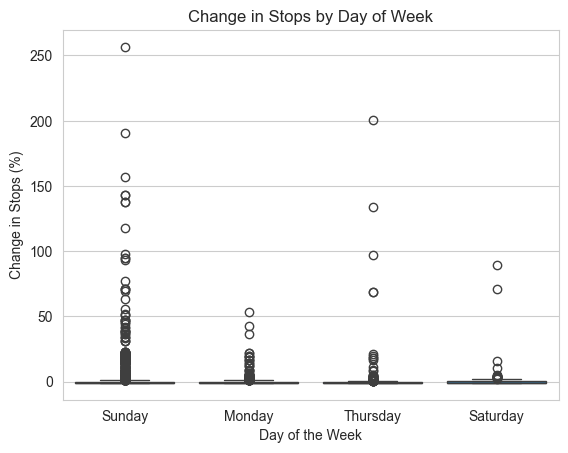

In [37]:
sns.boxplot(data=final_df,
             y="percent_change_in_stops",
             x="Day")

plt.title("Change in Stops by Day of Week")
plt.ylabel("Change in Stops (%)")
plt.xlabel("Day of the Week")
plt.show()

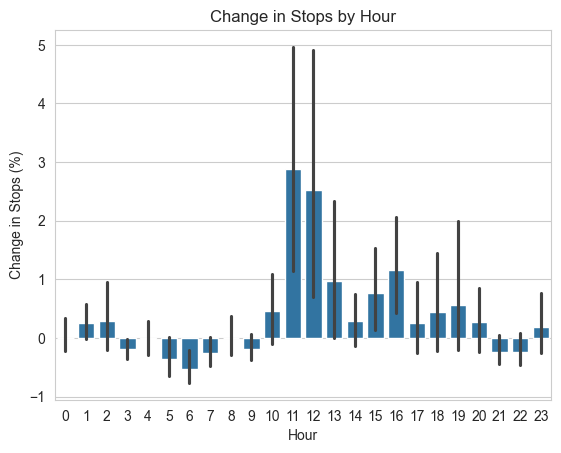

In [38]:
sns.barplot(data=final_df,
             y="percent_change_in_stops",
             x="hour")

plt.title("Change in Stops by Hour")
plt.xlabel("Hour")
plt.ylabel("Change in Stops (%)")
plt.show()

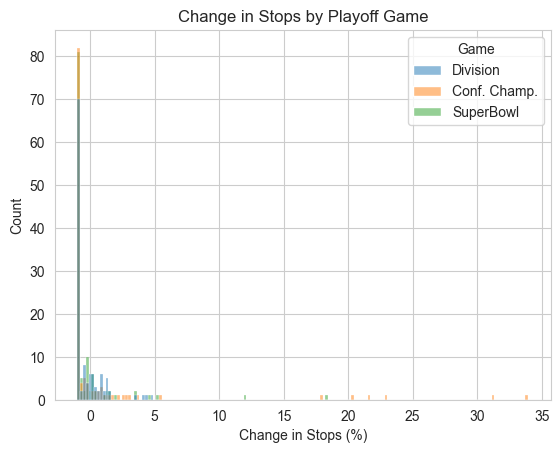

In [39]:
# This one might not tell us much considering these games are not common for all seasons but
# felt it would be interesting to see
playoffs = final_df[final_df.RegularSeason == 0]
sns.histplot(data=playoffs,
             x="percent_change_in_stops",
             hue="Game")

plt.title("Change in Stops by Playoff Game")
plt.xlabel("Change in Stops (%)")
plt.show()

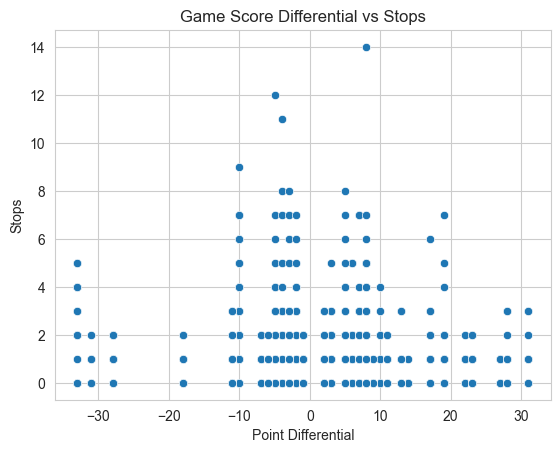

In [40]:
duringGame = final_df[final_df.game_period == "during"]
sns.scatterplot(data=duringGame,
             y="stop_count",
             x="PointDiff")
plt.title("Game Score Differential vs Stops")
plt.xlabel("Point Differential")
plt.ylabel("Stops")
plt.show()

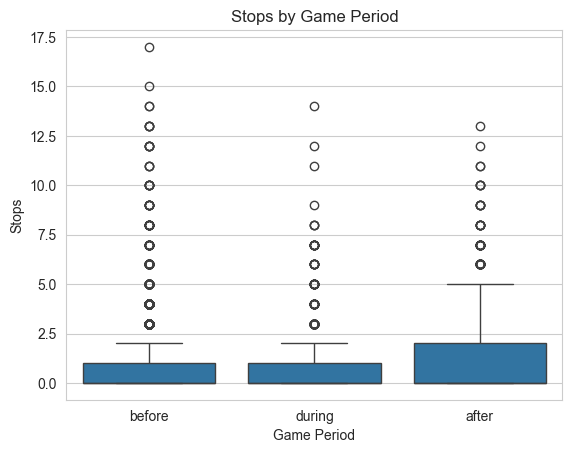

In [41]:
sns.boxplot(data=final_df,
             y="stop_count",
             x="game_period")

plt.title("Stops by Game Period")
plt.ylabel("Stops")
plt.xlabel("Game Period")
plt.show()